DATASET LOADED
Shape: (10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows:
0

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Target percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

Features used for prediction:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Numerical columns:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Categorical columns:
['Geography', 'Gender']

Training records: 8000
Testing records: 2000

TRAINING MODEL
Training completed successfully.

MODEL PERFORMANCE
Accuracy  : 85.05%
Precision : 65.88%
Recall

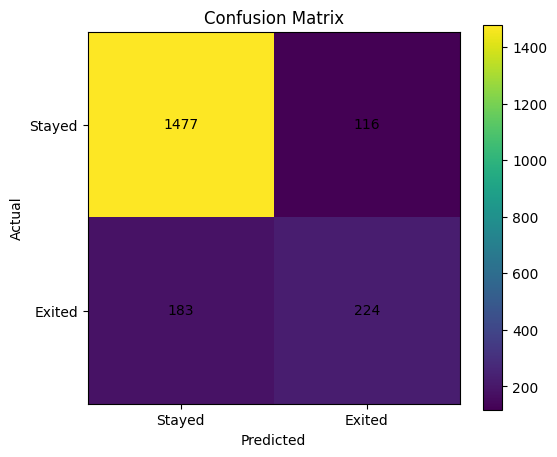


NEW CUSTOMER PREDICTION
Churn Prediction: Will Stay
Churn Probability: 33.71%
Risk Level: LOW

SAMPLE CUSTOMER PREDICTIONS


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Actual Churn,Predicted Churn,Churn Probability %
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,64.04
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,30.55
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,94.21
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,14.51
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,10.57
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,61.72
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,13.06
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,1,89.03
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,26.52
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,7.93



TOP 15 IMPORTANT FEATURES


,Feature,Importance
1,numeric__Age,0.275526
4,numeric__NumOfProducts,0.148451
3,numeric__Balance,0.134349
7,numeric__EstimatedSalary,0.118720
0,numeric__CreditScore,0.114033
2,numeric__Tenure,0.071050
6,numeric__IsActiveMember,0.042514
9,categorical__Geography_Germany,0.030979
5,numeric__HasCrCard,0.016350
8,categorical__Geography_France,0.013402


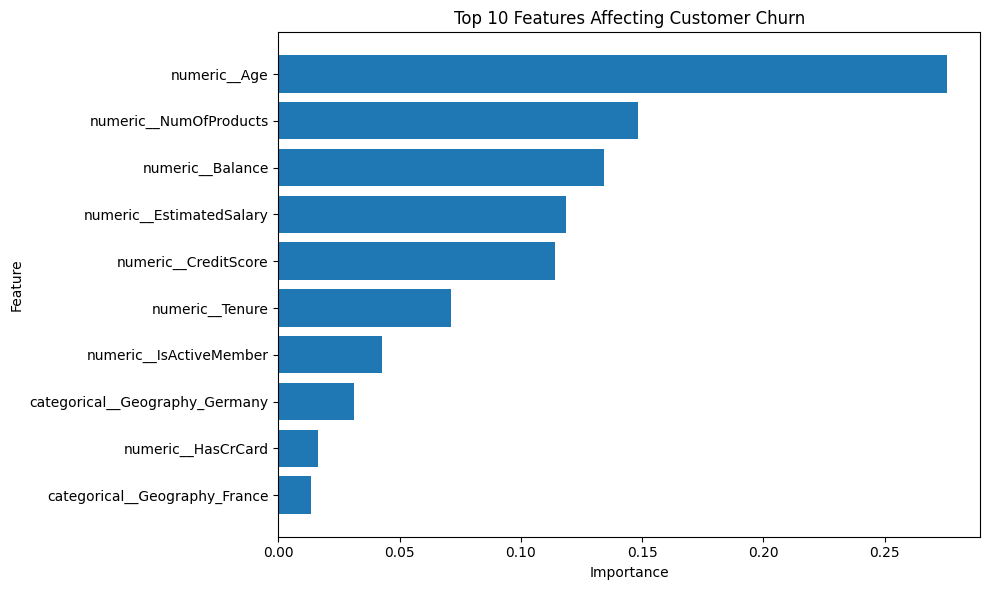


MODEL SAVED
/content/customer_churn_random_forest.pkl

Prediction file saved:
/content/customer_churn_predictions.csv

PROJECT COMPLETED

Dataset:
/content/Churn_Modelling.csv

Total Customers:
10000

Training Customers:
8000

Testing Customers:
2000

Algorithm:
Random Forest Classifier

Accuracy:
85.05%

Precision:
65.88%

Recall:
55.04%

F1 Score:
59.97%

ROC-AUC:
0.8573

Model:
/content/customer_churn_random_forest.pkl

Predictions:
/content/customer_churn_predictions.csv



In [6]:
# ============================================================
# CUSTOMER CHURN PREDICTION
# Dataset: /content/Churn_Modelling.csv
# Complete Google Colab - SINGLE CELL
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# -----------------------------
# 2. LOAD DATASET
# -----------------------------

FILE_PATH = "/content/Churn_Modelling.csv"

df = pd.read_csv(FILE_PATH)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

# -----------------------------
# 3. BASIC DATA INFORMATION
# -----------------------------

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["Exited"].value_counts())

print("\nTarget percentage:")
print(
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# -----------------------------
# 4. REMOVE UNNECESSARY COLUMNS
# -----------------------------

# Standard Churn_Modelling dataset contains:
#
# RowNumber
# CustomerId
# Surname
# CreditScore
# Geography
# Gender
# Age
# Tenure
# Balance
# NumOfProducts
# HasCrCard
# IsActiveMember
# EstimatedSalary
# Exited

columns_to_remove = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

existing_remove_columns = [
    col for col in columns_to_remove
    if col in df.columns
]

df_model = df.drop(
    columns=existing_remove_columns
)

# -----------------------------
# 5. DEFINE X AND Y
# -----------------------------

TARGET = "Exited"

X = df_model.drop(
    columns=[TARGET]
)

y = df_model[TARGET]

print("\nFeatures used for prediction:")
print(X.columns.tolist())

# -----------------------------
# 6. IDENTIFY COLUMNS
# -----------------------------

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("\nNumerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

# -----------------------------
# 7. PREPROCESSING
# -----------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

# -----------------------------
# 8. TRAIN / TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))

# -----------------------------
# 9. RANDOM FOREST MODEL
# -----------------------------

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# -----------------------------
# 10. TRAIN MODEL
# -----------------------------

print("\n" + "=" * 70)
print("TRAINING MODEL")
print("=" * 70)

model.fit(
    X_train,
    y_train
)

print("Training completed successfully.")

# -----------------------------
# 11. PREDICT TEST DATA
# -----------------------------

y_pred = model.predict(
    X_test
)

y_probability = model.predict_proba(
    X_test
)[:, 1]

# -----------------------------
# 12. MODEL EVALUATION
# -----------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")

# -----------------------------
# 13. CLASSIFICATION REPORT
# -----------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Stayed",
            "Exited"
        ],
        zero_division=0
    )
)

# -----------------------------
# 14. CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Stayed", "Exited"]
)

plt.yticks(
    [0, 1],
    ["Stayed", "Exited"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

# -----------------------------
# 15. CREATE PREDICTION FUNCTION
# -----------------------------

def predict_customer(
    customer_data,
    threshold=0.50
):

    customer_df = pd.DataFrame(
        [customer_data]
    )

    probability = model.predict_proba(
        customer_df
    )[0][1]

    prediction = (
        1
        if probability >= threshold
        else 0
    )

    if probability >= 0.70:

        risk = "HIGH"

    elif probability >= 0.40:

        risk = "MEDIUM"

    else:

        risk = "LOW"

    return {
        "Churn Prediction":
            "Will Leave"
            if prediction == 1
            else "Will Stay",

        "Churn Probability":
            f"{probability * 100:.2f}%",

        "Risk Level":
            risk
    }

# -----------------------------
# 16. PREDICT A NEW CUSTOMER
# -----------------------------

new_customer = {
    "CreditScore": 600,
    "Geography": "France",
    "Gender": "Female",
    "Age": 40,
    "Tenure": 3,
    "Balance": 60000,
    "NumOfProducts": 1,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 50000
}

result = predict_customer(
    new_customer
)

print("\n" + "=" * 70)
print("NEW CUSTOMER PREDICTION")
print("=" * 70)

for key, value in result.items():

    print(
        f"{key}: {value}"
    )

# -----------------------------
# 17. PREDICT FIRST 10 CUSTOMERS
# -----------------------------

sample_customers = df_model.drop(
    columns=[TARGET]
).head(10)

sample_predictions = model.predict(
    sample_customers
)

sample_probabilities = model.predict_proba(
    sample_customers
)[:, 1]

prediction_results = sample_customers.copy()

prediction_results[
    "Actual Churn"
] = df_model[TARGET].head(10).values

prediction_results[
    "Predicted Churn"
] = sample_predictions

prediction_results[
    "Churn Probability %"
] = (
    sample_probabilities * 100
).round(2)

print("\n" + "=" * 70)
print("SAMPLE CUSTOMER PREDICTIONS")
print("=" * 70)

display(prediction_results)

# -----------------------------
# 18. FEATURE IMPORTANCE
# -----------------------------

rf_model = model.named_steps[
    "classifier"
]

preprocessor_fitted = model.named_steps[
    "preprocessor"
]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({

    "Feature":
        feature_names,

    "Importance":
        rf_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 70)

display(
    feature_importance.head(15)
)

# -----------------------------
# 19. FEATURE IMPORTANCE CHART
# -----------------------------

top_features = (
    feature_importance
    .head(10)
    .sort_values(
        "Importance"
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 10 Features Affecting Customer Churn"
)

plt.tight_layout()

plt.show()

# -----------------------------
# 20. SAVE COMPLETE MODEL
# -----------------------------

MODEL_PATH = (
    "/content/customer_churn_random_forest.pkl"
)

joblib.dump(
    model,
    MODEL_PATH
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(
    MODEL_PATH
)

# -----------------------------
# 21. SAVE PREDICTIONS
# -----------------------------

OUTPUT_FILE = (
    "/content/customer_churn_predictions.csv"
)

all_probabilities = model.predict_proba(
    X
)[:, 1]

all_predictions = (
    all_probabilities >= 0.50
).astype(int)

output_df = df.copy()

output_df[
    "Predicted_Exited"
] = all_predictions

output_df[
    "Churn_Probability"
] = (
    all_probabilities * 100
).round(2)

output_df[
    "Risk_Level"
] = pd.cut(
    all_probabilities,
    bins=[
        -np.inf,
        0.40,
        0.70,
        np.inf
    ],
    labels=[
        "LOW",
        "MEDIUM",
        "HIGH"
    ]
)

output_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nPrediction file saved:")
print(OUTPUT_FILE)

# -----------------------------
# 22. FINAL SUMMARY
# -----------------------------

print("\n" + "=" * 70)
print("PROJECT COMPLETED")
print("=" * 70)

print(f"""
Dataset:
{FILE_PATH}

Total Customers:
{len(df)}

Training Customers:
{len(X_train)}

Testing Customers:
{len(X_test)}

Algorithm:
Random Forest Classifier

Accuracy:
{accuracy * 100:.2f}%

Precision:
{precision * 100:.2f}%

Recall:
{recall * 100:.2f}%

F1 Score:
{f1 * 100:.2f}%

ROC-AUC:
{roc_auc:.4f}

Model:
{MODEL_PATH}

Predictions:
{OUTPUT_FILE}
""")